In [51]:
!pip install -q ucimlrepo
!pip install -q joblib

# Importing Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.inspection import permutation_importance
from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# Dataset Loading

In [53]:
wine_quality = fetch_ucirepo(id=186)
X = wine_quality.data.features
y = wine_quality.data.targets
print("Dataset loaded")
print("Metadata:",wine_quality.metadata)
print("Variables:",display(wine_quality.variables))

Dataset loaded
Metadata: {'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': '

,name,role,type,demographic,description,units,missing_values
0,fixed_acidity,Feature,Continuous,None,None,None,no
1,volatile_acidity,Feature,Continuous,None,None,None,no
2,citric_acid,Feature,Continuous,None,None,None,no
3,residual_sugar,Feature,Continuous,None,None,None,no
4,chlorides,Feature,Continuous,None,None,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,None,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,None,None,no
7,density,Feature,Continuous,None,None,None,no
8,pH,Feature,Continuous,None,None,None,no
9,sulphates,Feature,Continuous,None,None,None,no


Variables: None


# Creating dataframe

In [54]:
df = pd.concat([X, y], axis=1)
print("Shape:",df.shape)
display(df.head())

Shape: (6497, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [56]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# Missing and Duplicates handling

In [57]:
#no missing values(df.info() shows this)
#check duplicates
duplicate=df.duplicated().sum()
print("Duplicate Count:",duplicate)
if duplicate>0:
  df=df.drop_duplicates().reset_index(drop=True)
print(df.shape)

Duplicate Count: 1179
(5318, 12)


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5318 entries, 0 to 5317
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5318 non-null   float64
 1   volatile_acidity      5318 non-null   float64
 2   citric_acid           5318 non-null   float64
 3   residual_sugar        5318 non-null   float64
 4   chlorides             5318 non-null   float64
 5   free_sulfur_dioxide   5318 non-null   float64
 6   total_sulfur_dioxide  5318 non-null   float64
 7   density               5318 non-null   float64
 8   pH                    5318 non-null   float64
 9   sulphates             5318 non-null   float64
 10  alcohol               5318 non-null   float64
 11  quality               5318 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 498.7 KB


# Target Distribution (before classification-ready data)

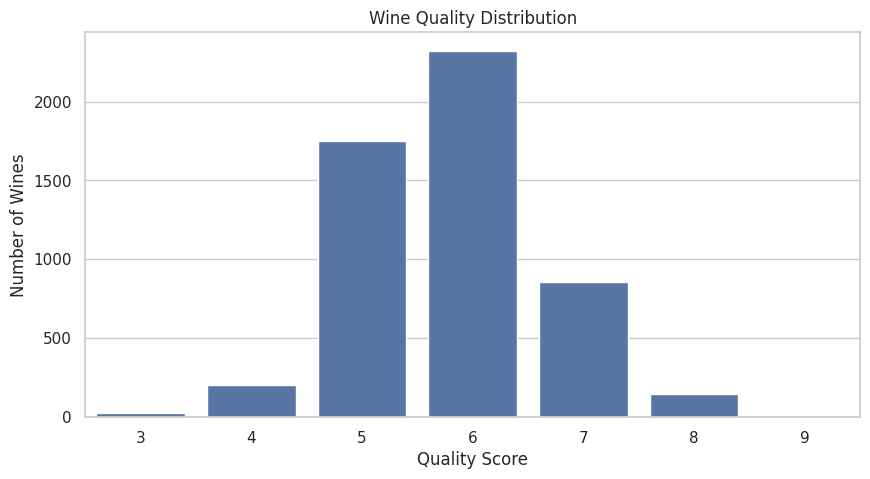

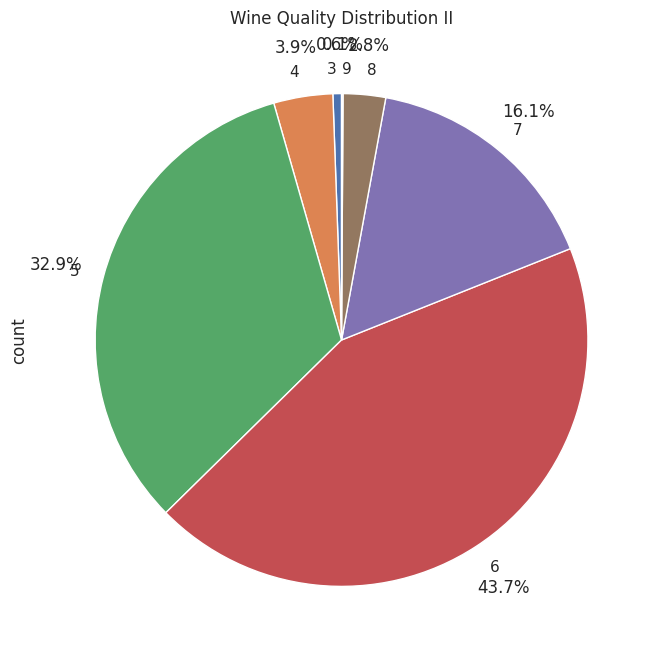

In [59]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="quality", order=sorted(df["quality"].unique()))
plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()


plt.figure(figsize=(8,8))
df["quality"].value_counts().sort_index().plot(kind="pie", autopct="%1.1f%%", startangle=90, pctdistance=1.2)
plt.title("Wine Quality Distribution II")
plt.show()

# Classification categories

In [60]:
#classification target
def quality_category(q):
    if q <= 5:
        return "Low"
    elif q == 6:
        return "Medium"
    else:
        return "High"


df["quality_category"] = df["quality"].apply(quality_category)
print(df["quality_category"].value_counts())

quality_category
Medium    2323
Low       1987
High      1008
Name: count, dtype: int64


# Data Distribution (after classification categories)

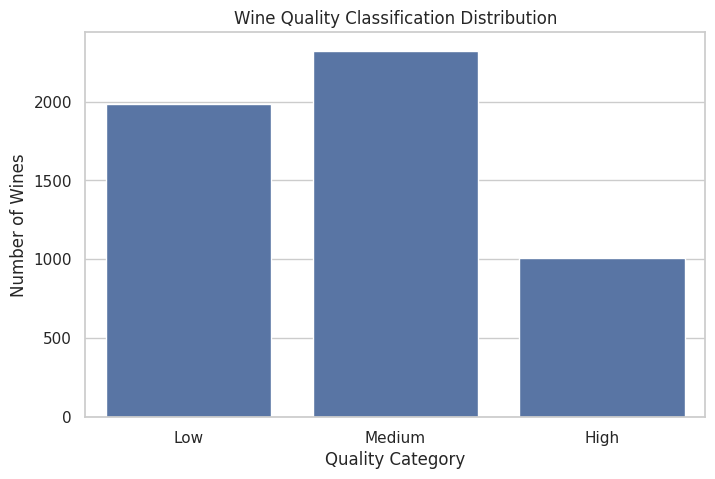

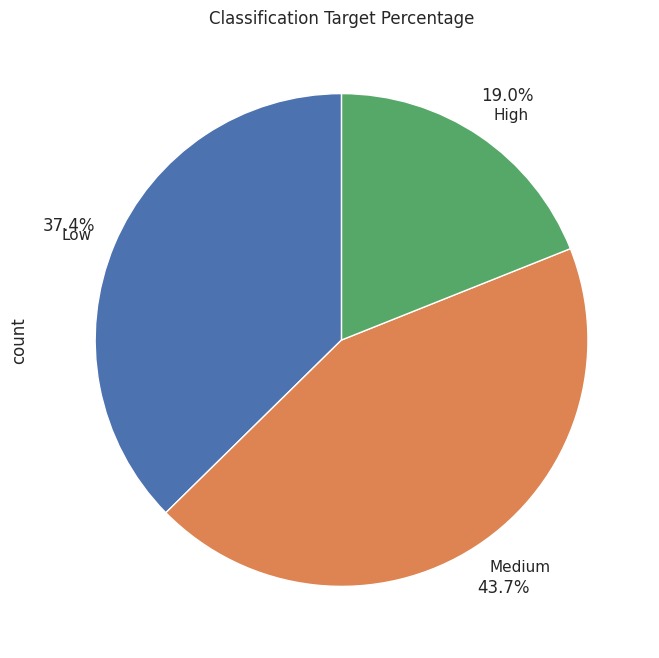

In [61]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality_category", order=["Low", "Medium", "High"])
plt.title("Wine Quality Classification Distribution")
plt.xlabel("Quality Category")
plt.ylabel("Number of Wines")
plt.show()


plt.figure(figsize=(8, 8))
df["quality_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="pie", autopct="%1.1f%%", startangle=90, pctdistance=1.2)
plt.title("Classification Target Percentage")
plt.show()

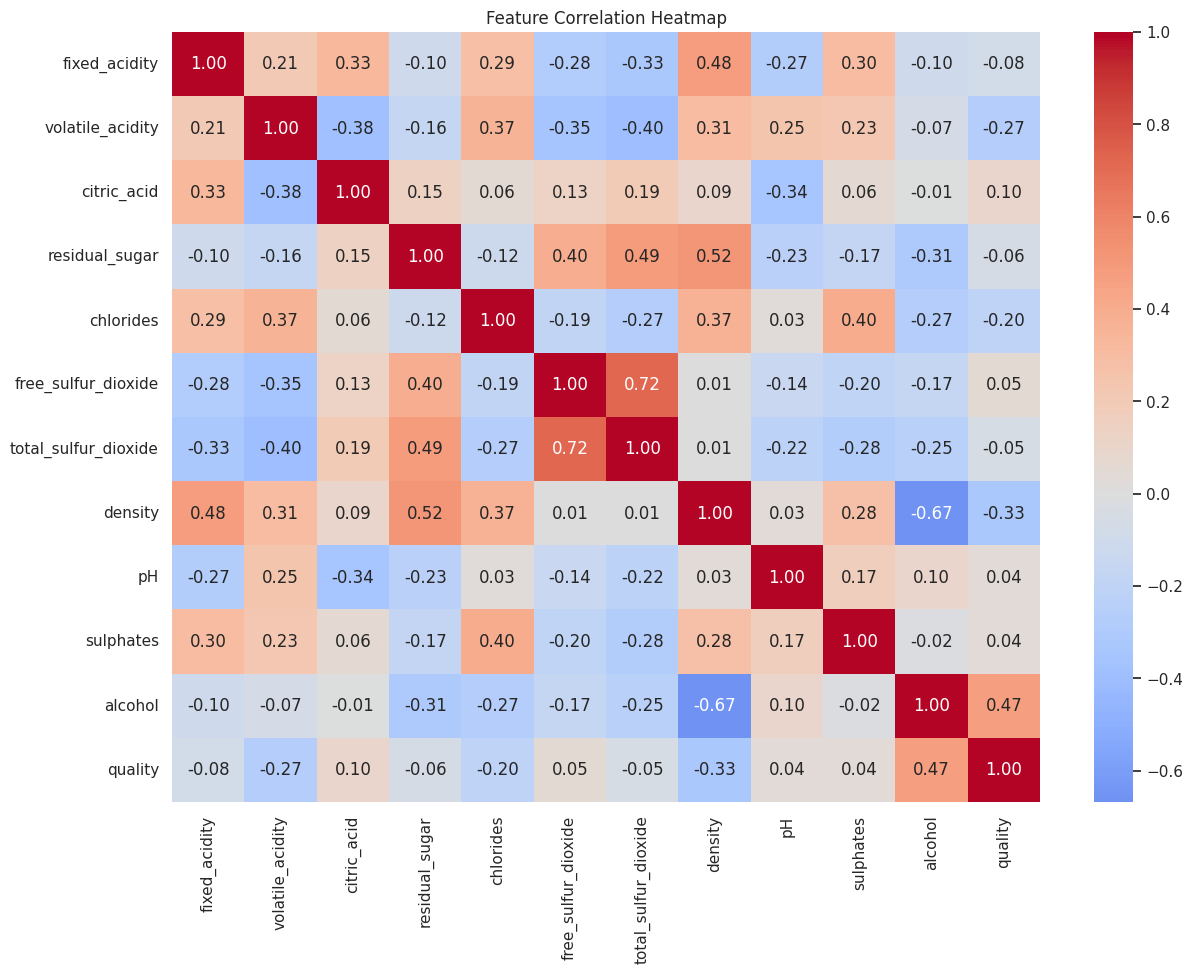

In [62]:
feature_columns = [
    col for col in df.columns
    if col not in ["quality", "quality_category"]
]

plt.figure(figsize=(14, 10))
correlation_matrix = df[feature_columns + ["quality"] + ["quality_category"]].corr()
sns.heatmap(
correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()

# Outliers Visualization
We do not remove outliers from Wine dataset as they can contain legitimate minority cases important wines

,Feature,Outlier Count,Outlier Percentage
0,fixed_acidity,304,5.716435
1,volatile_acidity,279,5.246333
4,chlorides,237,4.456563
9,sulphates,163,3.065062
2,citric_acid,143,2.688981
3,residual_sugar,141,2.651373
8,pH,49,0.921399
5,free_sulfur_dioxide,44,0.827379
6,total_sulfur_dioxide,10,0.188041
7,density,3,0.056412


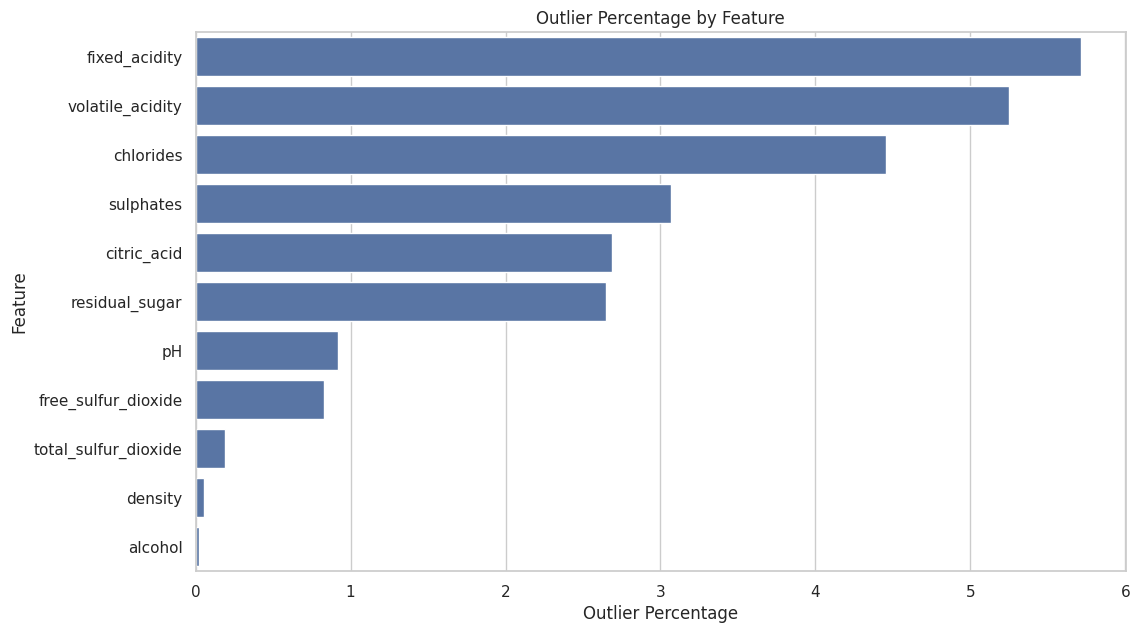

In [63]:
outlier_results = []
for feature in feature_columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    count = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ).sum()
    percentage = (count / len(df)) * 100
    outlier_results.append([feature,count,percentage])

outlier_df = pd.DataFrame(
    outlier_results,
    columns=["Feature","Outlier Count","Outlier Percentage"]
)

display(
    outlier_df.sort_values("Outlier Percentage",ascending=False)
)

#visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=outlier_df.sort_values("Outlier Percentage",ascending=False),
    x="Outlier Percentage",
    y="Feature"
)
plt.title("Outlier Percentage by Feature")
plt.xlabel("Outlier Percentage")
plt.ylabel("Feature")
plt.show()


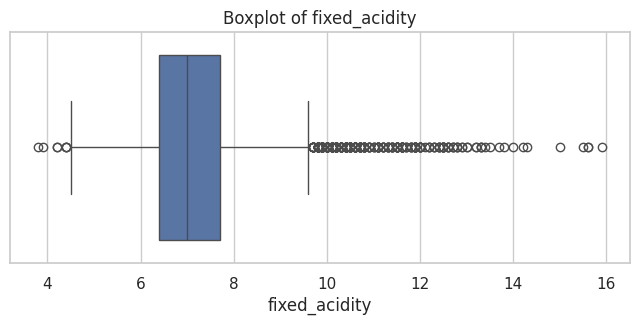

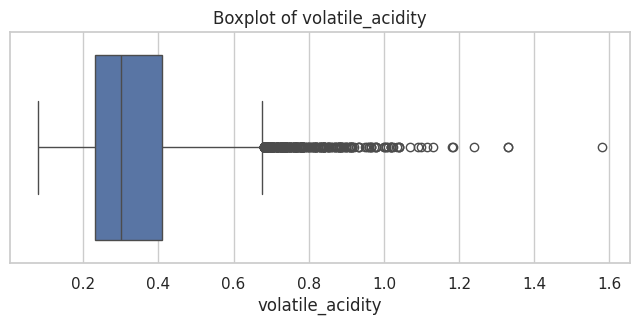

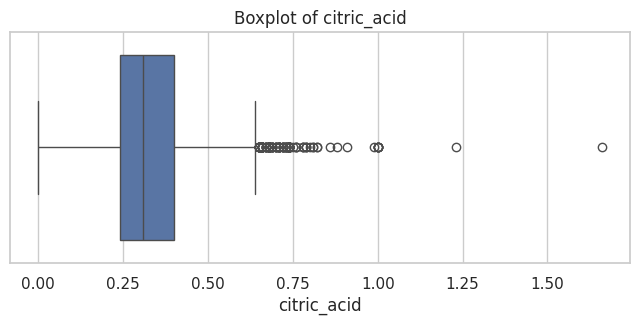

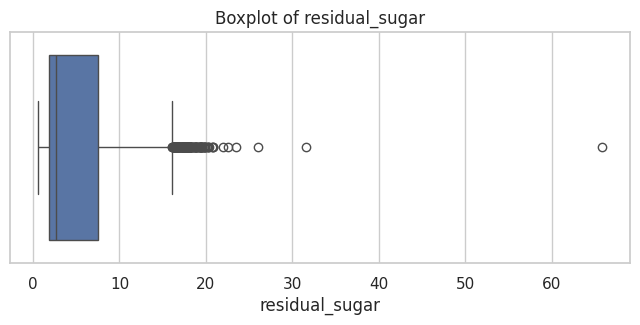

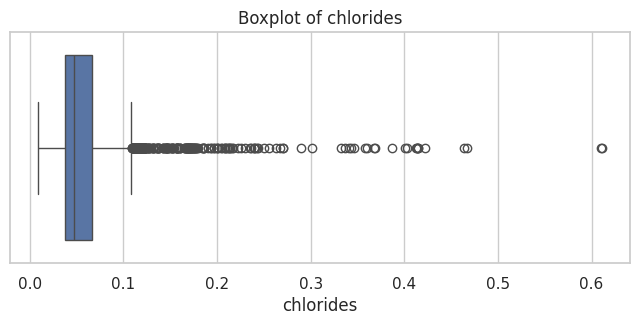

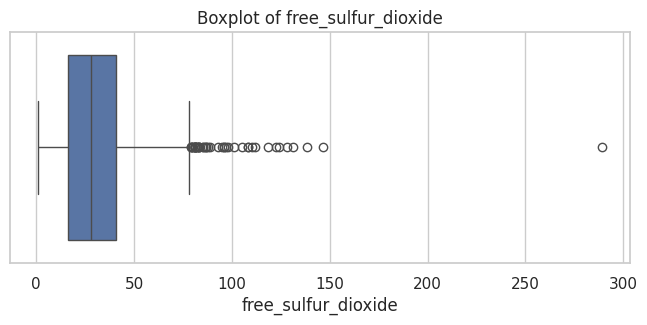

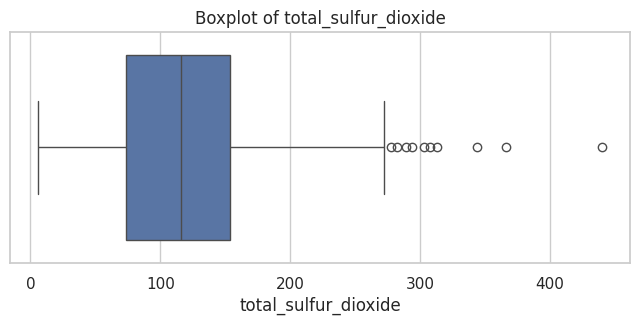

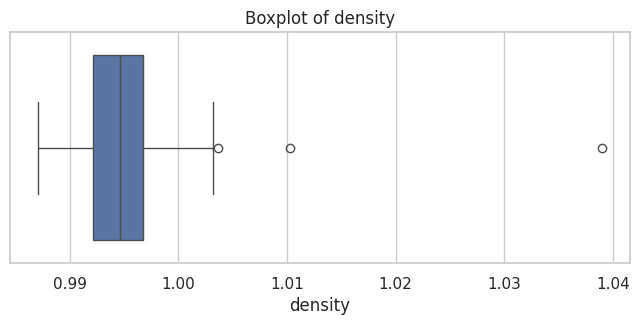

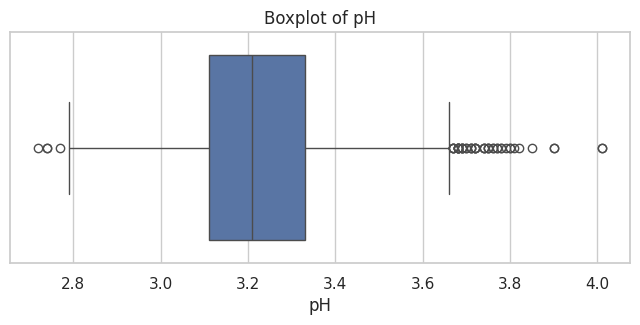

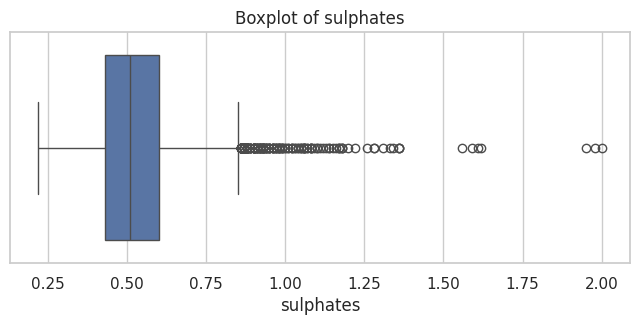

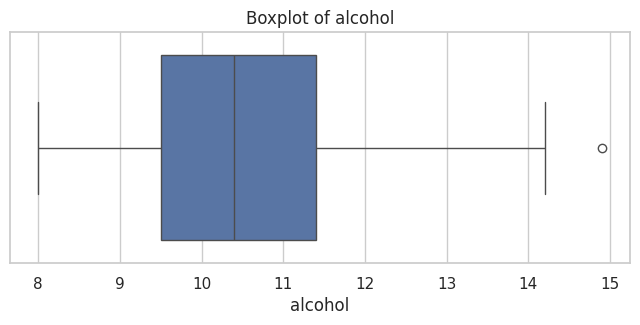

In [64]:
for feature in feature_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.show()

# Feature Engineering

In [65]:
df["total_acidity"] = (df["fixed_acidity"] + df["volatile_acidity"] + df["citric_acid"])
df["sulfur_ratio"] = (df["free_sulfur_dioxide"] / (df["total_sulfur_dioxide"] + 1))
df["alcohol_density_ratio"] = (df["alcohol"] / (df["density"] + 1e-6))
df["sugar_acidity_ratio"] = (df["residual_sugar"] / (df["fixed_acidity"] + 1))
engineered_features = ["total_acidity","sulfur_ratio","alcohol_density_ratio","sugar_acidity_ratio"]
display(df[engineered_features].describe())


,total_acidity,sulfur_ratio,alcohol_density_ratio,sugar_acidity_ratio
count,5318.000000,5318.000000,5318.000000,5318.000000
mean,7.878215,0.281955,10.609638,0.634240
std,1.412920,0.121417,1.215012,0.576890
min,4.130000,0.022222,8.025030,0.061856
25%,6.990000,0.200000,9.546242,0.208955
50%,7.590000,0.266530,10.445952,0.325151
75%,8.420000,0.344074,11.453074,0.961414
max,17.045000,0.833333,14.935831,7.477273


# Train Test Splitting

In [66]:
X = df[feature_columns + engineered_features]
y = df["quality_category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

X_train: (4254, 15)
X_test: (1064, 15)
y_train: (4254,)
y_test: (1064,)
quality_category
Medium    1858
Low       1590
High       806
Name: count, dtype: int64
quality_category
Medium    465
Low       397
High      202
Name: count, dtype: int64


# Models Definition

In [67]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=False, class_weight="balanced", random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_split=10, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

# Cross-Validation

In [68]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}
cv_results = []
for name, model in models.items():
    scores = cross_validate(model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Macro F1 Mean": scores["test_macro_f1"].mean(),
        "Macro F1 Std": scores["test_macro_f1"].std(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced Accuracy Std": scores["test_balanced_accuracy"].std()
    })
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("Macro F1 Mean",ascending=False).reset_index(drop=True)
display(cv_results_df)

,Model,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std,Balanced Accuracy Mean,Balanced Accuracy Std
0,Random Forest,0.614484,0.016716,0.590164,0.019965,0.576560,0.017753
1,Gradient Boosting,0.603436,0.010178,0.579682,0.013986,0.567824,0.012476
2,KNN,0.564178,0.019324,0.555046,0.020765,0.555955,0.018104
3,SVM,0.557592,0.009730,0.549966,0.010499,0.597771,0.011769
4,Logistic Regression,0.548894,0.010639,0.543415,0.008791,0.586875,0.012394
5,Decision Tree,0.516448,0.018510,0.509627,0.020586,0.551112,0.012092


# Model Scoring Comparison

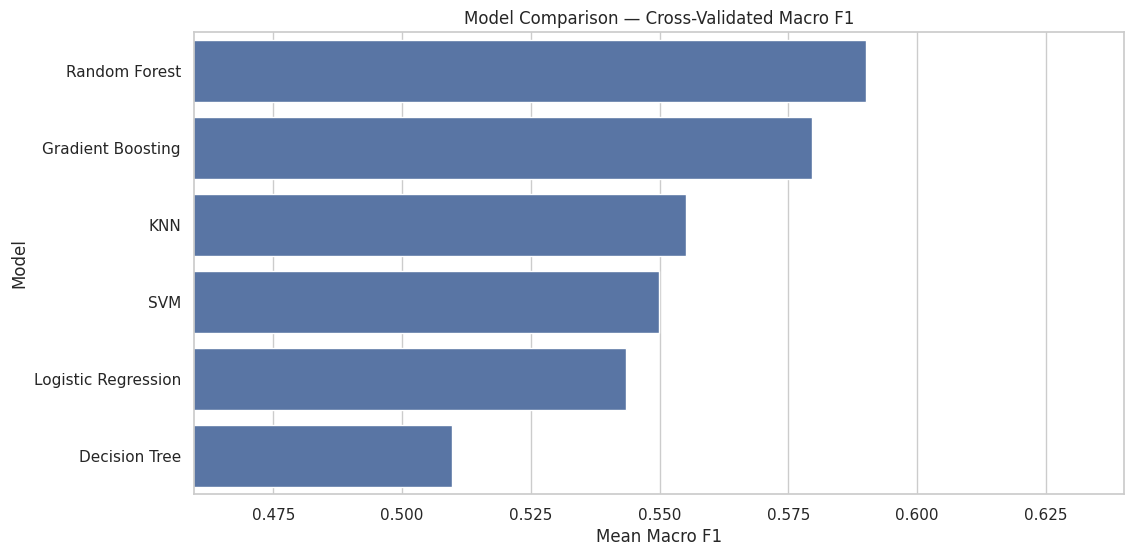

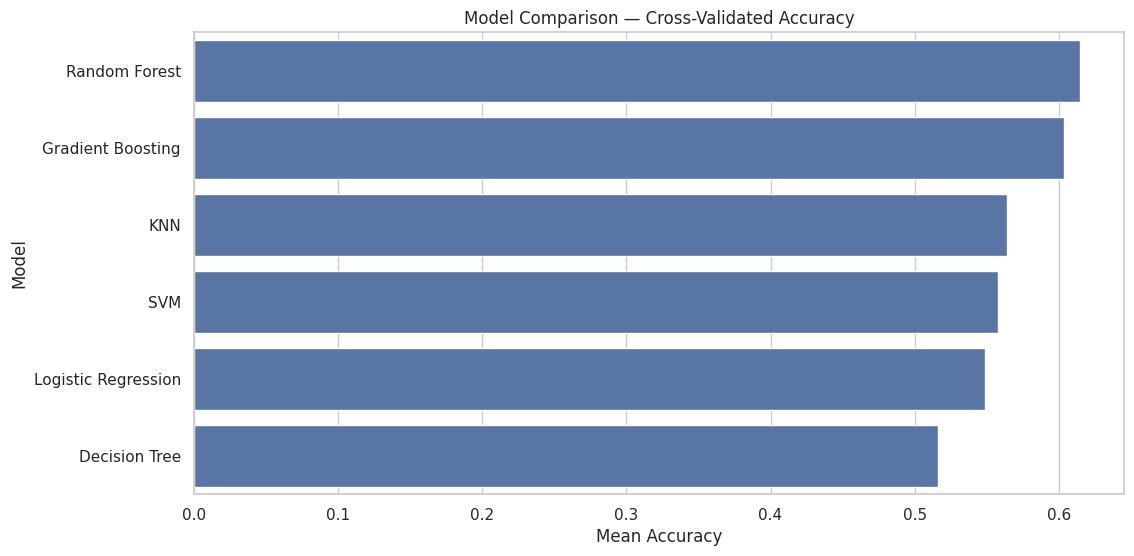

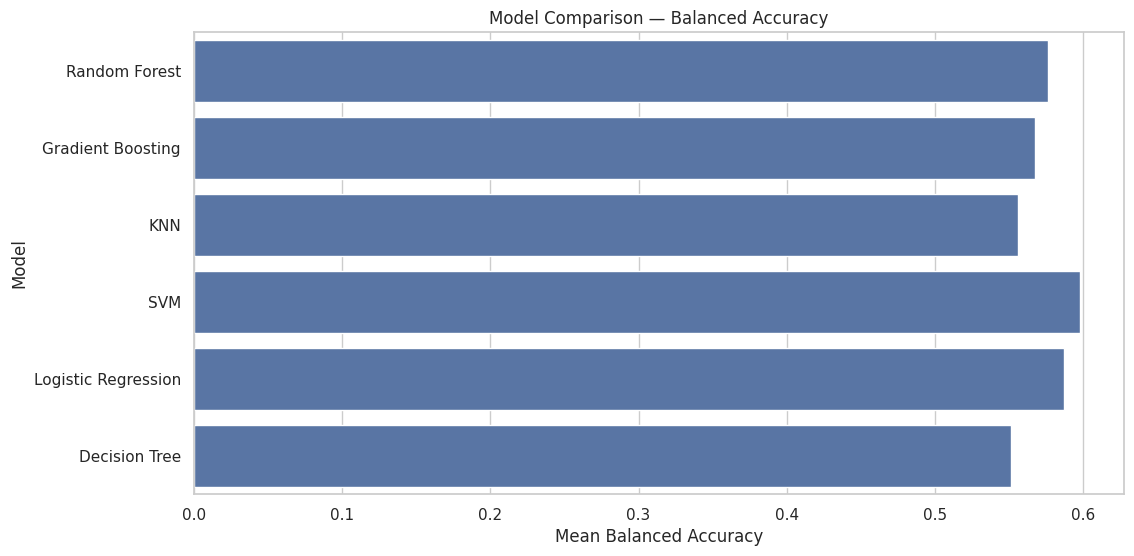

In [69]:
#Macro F1
plt.figure(figsize=(12, 6))
sns.barplot(data=cv_results_df,x="Macro F1 Mean",y="Model")
plt.title("Model Comparison — Cross-Validated Macro F1")
plt.xlabel("Mean Macro F1")
plt.ylabel("Model")
plt.xlim(max(0, cv_results_df["Macro F1 Mean"].min() - 0.05),min(1, cv_results_df["Macro F1 Mean"].max() + 0.05))
plt.show()


#Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(data=cv_results_df,x="Accuracy Mean",y="Model")
plt.title("Model Comparison — Cross-Validated Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.show()


#Balanced Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(data=cv_results_df,x="Balanced Accuracy Mean",y="Model")
plt.title("Model Comparison — Balanced Accuracy")
plt.xlabel("Mean Balanced Accuracy")
plt.ylabel("Model")
plt.show()

# Top 3 models
Top 3 models are chosen based on Macro F1 as the classes(Low, Medium, High) are imbalanced and it averages the F1 score of each class equally

In [70]:
top_models = (cv_results_df.head(3)["Model"].tolist())
print("Top 3 models:")
i=1
for model_name in top_models:
  print(f"{i}. {model_name}")
  i+=1

Top 3 models:
1. Random Forest
2. Gradient Boosting
3. KNN


# Hyperparameter Tuning of Top Models

In [72]:
param_distributions = {
    "Random Forest": {
        "n_estimators": [200,300,400],
        "max_depth": [None,10,15,20],
        "min_samples_split": [2,5,10],
        "min_samples_leaf": [1,2,4],
        "max_features": ["sqrt","log2"]
      },
    "Gradient Boosting": {
        "n_estimators": [100,150,200],
        "learning_rate": [0.03,0.05,0.1],
        "max_depth": [2,3,4],
        "min_samples_split": [2,5],
        "min_samples_leaf": [1,2]
      },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }
}

tuning_cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)

tuned_models = {}
tuning_results = []
for model_name in top_models:
    search = RandomizedSearchCV(estimator=models[model_name],param_distributions=param_distributions[model_name],n_iter=8,
        scoring="f1_macro",
        cv=tuning_cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    tuned_models[model_name] = search.best_estimator_
    tuning_results.append({
        "Model": model_name,
        "Best CV Macro F1": search.best_score_,
        "Best Parameters": search.best_params_
    })


tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values("Best CV Macro F1",ascending=False).reset_index(drop=True)
display(tuning_results_df)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Model,Best CV Macro F1,Best Parameters
0,Random Forest,0.593295,"{'n_estimators': 200, 'min_samples_split': 10,..."
1,Gradient Boosting,0.581946,"{'n_estimators': 200, 'min_samples_split': 2, ..."
2,KNN,0.574116,"{'model__weights': 'distance', 'model__p': 1, ..."


# Tuned Model Comparison

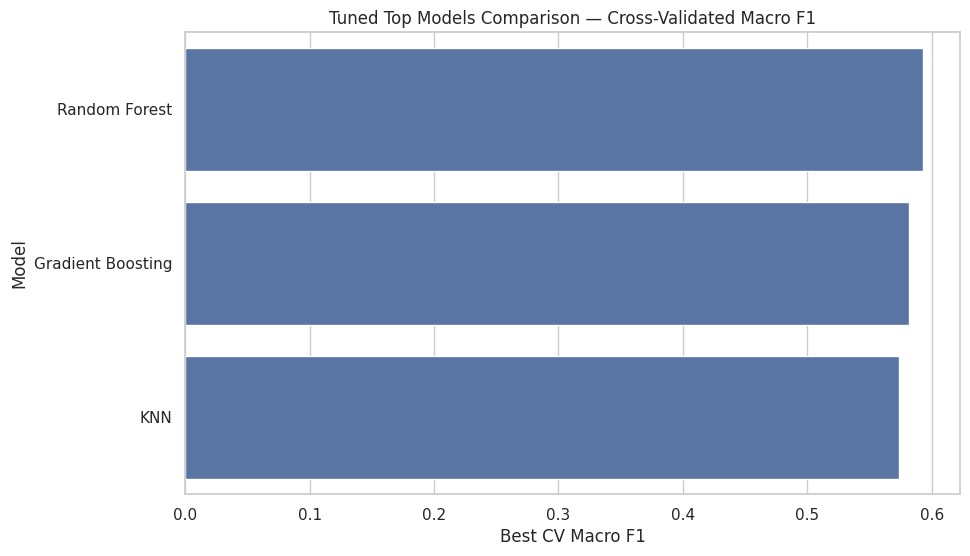

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tuning_results_df,
    x="Best CV Macro F1",
    y="Model"
)
plt.title("Tuned Top Models Comparison — Cross-Validated Macro F1")
plt.xlabel("Best CV Macro F1")
plt.ylabel("Model")
plt.show()

# Best Model

In [74]:
best_model_name = tuning_results_df.iloc[0]["Model"]
final_model = tuned_models[best_model_name]
print("Final Model:", best_model_name)
print("Best CV Macro F1:",tuning_results_df.iloc[0]["Best CV Macro F1"])
print("Best Parameters:", tuning_results_df.iloc[0]["Best Parameters"])

Final Model: Random Forest
Best CV Macro F1: 0.593295013148837
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


# Model Training and Evaluation

In [75]:
final_model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [76]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['Low' 'High' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Low' 'Medium'
 'Medium']


### Evaluation Metrics

In [77]:
final_accuracy = accuracy_score(y_test,y_pred)
final_macro_f1 = f1_score(y_test,y_pred,average="macro")
final_balanced_accuracy = balanced_accuracy_score(y_test,y_pred)

print("Final Model:", best_model_name)
print("Accuracy:", round(final_accuracy, 4))
print("Macro F1:", round(final_macro_f1, 4))
print("Balanced Accuracy:",round(final_balanced_accuracy, 4))

class_order=["Low", "Medium", "High"]
print(classification_report(y_test,y_pred,labels=class_order,target_names=class_order))

Final Model: Random Forest
Accuracy: 0.6598
Macro F1: 0.6498
Balanced Accuracy: 0.6503
              precision    recall  f1-score   support

         Low       0.71      0.74      0.73       397
      Medium       0.64      0.62      0.63       465
        High       0.59      0.59      0.59       202

    accuracy                           0.66      1064
   macro avg       0.65      0.65      0.65      1064
weighted avg       0.66      0.66      0.66      1064



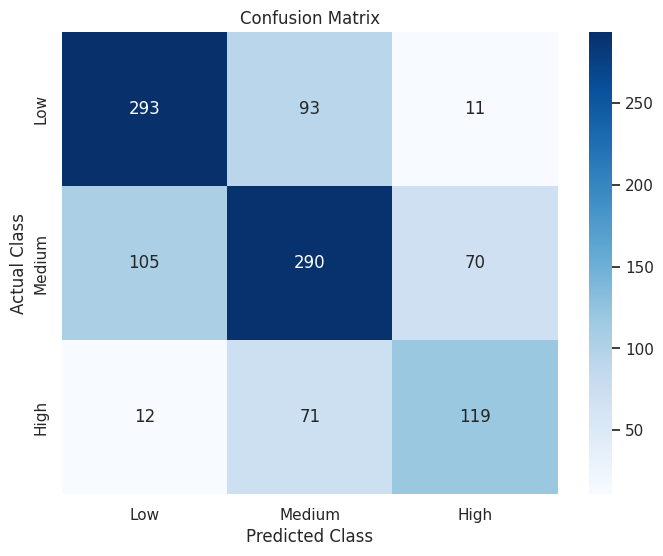

In [78]:
cm = confusion_matrix(y_test,y_pred,labels=class_order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_order,yticklabels=class_order)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [79]:
# Since this is a multiclass problem, we use One-vs-Rest.
# ROC-AUC evaluates how well the model separates classes based on predicted probabilities.
roc_auc = roc_auc_score(y_test,y_proba,multi_class="ovr",average="macro")
print(f"Multiclass ROC-AUC: {roc_auc:.4f}")

y_test_binary = pd.get_dummies(pd.Categorical(y_test,categories=class_order)).values
roc_auc_macro = roc_auc_score(y_test_binary,y_proba,multi_class="ovr",average="macro")
roc_auc_weighted = roc_auc_score(y_test_binary,y_proba,multi_class="ovr",average="weighted")
print("Macro ROC-AUC:", round(roc_auc_macro, 4))
print("Weighted ROC-AUC:", round(roc_auc_weighted, 4))

Multiclass ROC-AUC: 0.8099
Macro ROC-AUC: 0.3369
Weighted ROC-AUC: 0.3168


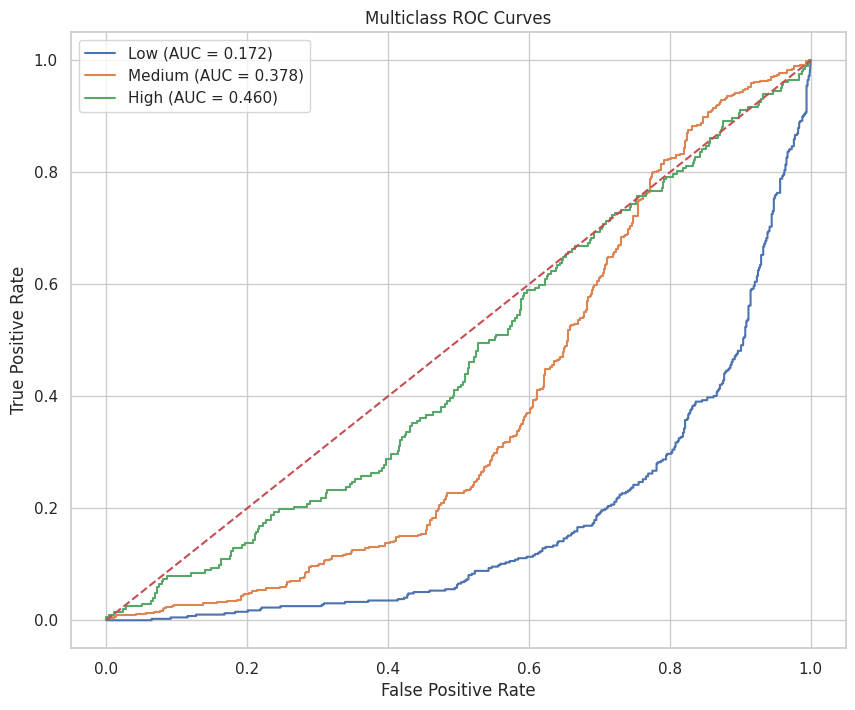

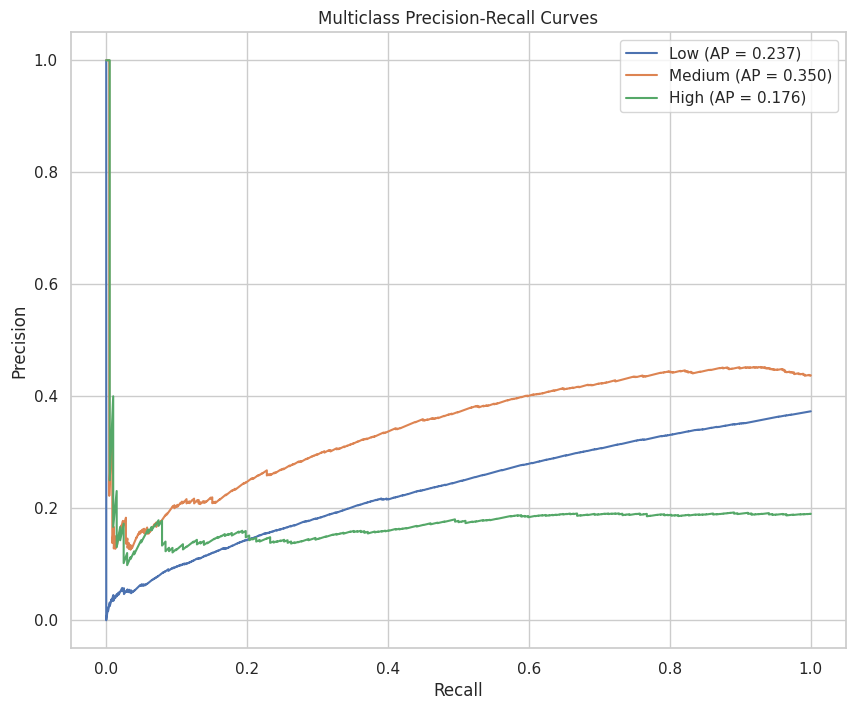

In [80]:
#roc-auc curve
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_order):
    fpr, tpr, _ = roc_curve(y_test_binary[:, i],y_proba[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,label=f"{class_name} (AUC = {class_auc:.3f})")


plt.plot([0, 1],[0, 1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()


#precision-recall curve
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_order):
    precision, recall, _ = precision_recall_curve(y_test_binary[:, i],y_proba[:, i])
    ap = average_precision_score(y_test_binary[:, i],y_proba[:, i])
    plt.plot(recall,precision,label=f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision-Recall Curves")
plt.legend()
plt.show()

# Feature Importance/ Permutation Importance

,Feature,Importance,Std
13,alcohol_density_ratio,0.101882,0.005365
10,alcohol,0.065385,0.007917
1,volatile_acidity,0.057529,0.008531
4,chlorides,0.028980,0.006193
6,total_sulfur_dioxide,0.027757,0.008437
8,pH,0.025924,0.006290
9,sulphates,0.024563,0.005938
2,citric_acid,0.024204,0.003701
7,density,0.018115,0.005365
5,free_sulfur_dioxide,0.017293,0.005236


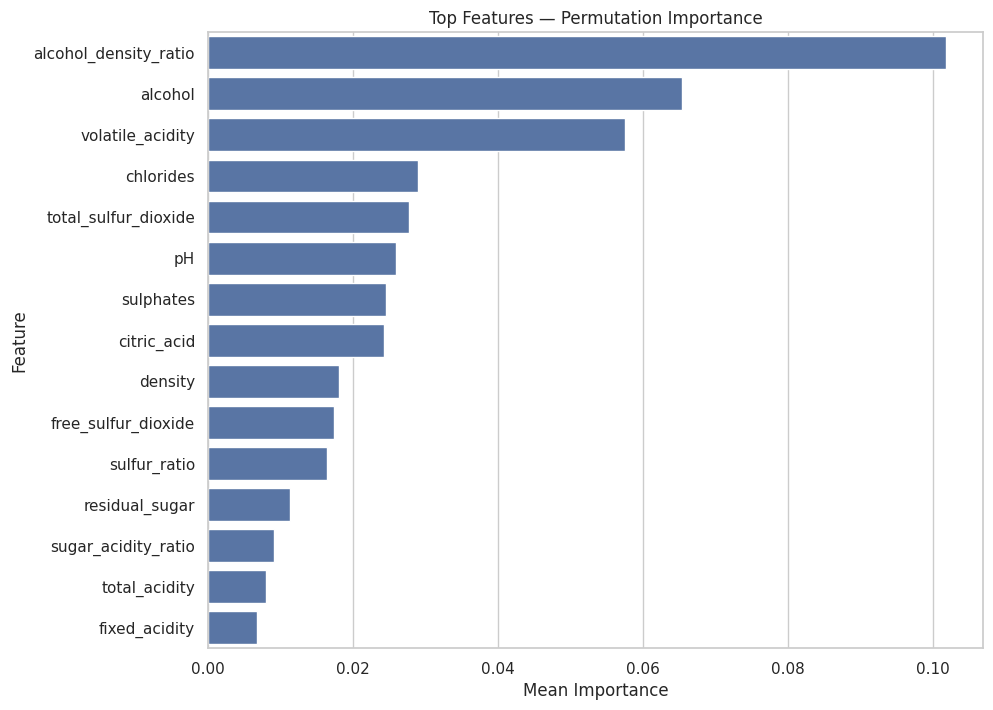

In [81]:
permutation = permutation_importance(final_model,X_test,y_test,scoring="f1_macro",n_repeats=10,random_state=42,n_jobs=-1)
importance_df = pd.DataFrame({"Feature": X_test.columns,"Importance": permutation.importances_mean,"Std": permutation.importances_std})
importance_df = importance_df.sort_values("Importance",ascending=False)
display(importance_df)
top_importance = importance_df.head(15)


#visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=top_importance,x="Importance",y="Feature")
plt.title("Top Features — Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

# Learning Curve


A learning curve shows how model performance changes as training data increases.

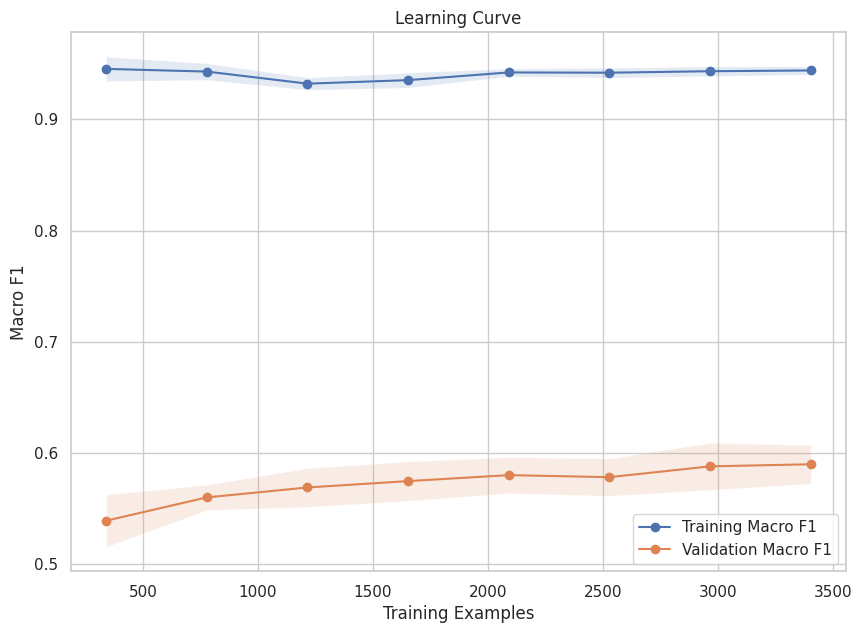

In [82]:
train_sizes, train_scores, validation_scores = learning_curve(final_model,X_train,y_train,cv=cv,scoring="f1_macro",train_sizes=np.linspace(0.1,1.0,8),n_jobs=-1)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)


plt.figure(figsize=(10, 7))
plt.plot(train_sizes,train_mean,marker="o",label="Training Macro F1")
plt.plot(train_sizes,validation_mean,marker="o",label="Validation Macro F1")
plt.fill_between(train_sizes,train_mean - train_std,train_mean + train_std,alpha=0.15)
plt.fill_between(train_sizes,validation_mean - validation_std,validation_mean + validation_std,alpha=0.15)
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Macro F1")
plt.legend()
plt.show()


# Model Testing and predictions

In [83]:
# SINGLE SAMPLE PREDICTION
sample = X_test.iloc[[0]]
sample_prediction = final_model.predict(sample)[0]
sample_probabilities = final_model.predict_proba(sample)[0]
print("Predicted Class:", sample_prediction)
print("Class Probabilities:")
for class_name, probability in zip(
    final_model.classes_,
    sample_probabilities
):
    print(
        f"{class_name}: {probability:.4f}"
    )

Predicted Class: Low
Class Probabilities:
High: 0.0240
Low: 0.5458
Medium: 0.4302


In [85]:

# PRODUCTION PREDICTION FUNCTION

def predict_wine_quality(
    model,
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):

    input_data = pd.DataFrame([{
        "fixed_acidity": fixed_acidity,
        "volatile_acidity": volatile_acidity,
        "citric_acid": citric_acid,
        "residual_sugar": residual_sugar,
        "chlorides": chlorides,
        "free_sulfur_dioxide": free_sulfur_dioxide,
        "total_sulfur_dioxide": total_sulfur_dioxide,
        "density": density,
        "pH": pH,
        "sulphates": sulphates,
        "alcohol": alcohol
    }])

    input_data["total_acidity"] = (
        input_data["fixed_acidity"] +
        input_data["volatile_acidity"] +
        input_data["citric_acid"]
    )

    input_data["sulfur_ratio"] = (
        input_data["free_sulfur_dioxide"] /
        (input_data["total_sulfur_dioxide"] + 1)
    )

    input_data["alcohol_density_ratio"] = (
        input_data["alcohol"] /
        (input_data["density"] + 1e-6)
    )

    input_data["sugar_acidity_ratio"] = (
        input_data["residual_sugar"] /
        (input_data["fixed_acidity"] + 1)
    )

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(
        input_data
    )[0]
    probability_dict = dict(
        zip(
            model.classes_,
            probabilities
        )
    )

    return prediction, probability_dict



prediction, probabilities = predict_wine_quality(
    final_model,
    fixed_acidity=0.4,
    volatile_acidity=0.70,
    citric_acid=0.00,
    residual_sugar=1.1,
    chlorides=0.076,
    free_sulfur_dioxide=4,
    total_sulfur_dioxide=29,
    density=0.0978,
    pH=7.51,
    sulphates=1.56,
    alcohol=33.4
)
print("Predicted Wine Quality:", prediction)
print("Probabilities:")
for class_name, probability in probabilities.items():
    print(
        f"{class_name}: {probability:.4f}"
    )



Predicted Wine Quality: High
Probabilities:
High: 0.4316
Low: 0.1599
Medium: 0.4085


In [86]:

# BATCH PREDICTION
batch_predictions = final_model.predict(
    X_test.head(10)
)

batch_probabilities = final_model.predict_proba(
    X_test.head(10)
)
batch_result = X_test.head(10).copy()
batch_result["Predicted Quality"] = batch_predictions
batch_result["Prediction Confidence"] = (
    np.max(
        batch_probabilities,
        axis=1
    )
)
display(
    batch_result[
        [
            "Predicted Quality",
            "Prediction Confidence"
        ]
    ]
)

,Predicted Quality,Prediction Confidence
3849,Low,0.545810
1195,High,0.597296
3830,Medium,0.438367
2773,Medium,0.730752
191,Low,0.509707
275,Medium,0.433366
4448,Medium,0.414684
4378,Low,0.856130
2467,Medium,0.542585
2459,Medium,0.491112
